## Minería de flujos - DGIM

Se simula la llegada de `data/final/` y se estima cuántos procesos con **postor único** hubo en cada ventana

### Imports

In [1]:
import os, socket, math, time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pyspark.sql import SparkSession, Window, functions as F
from collections import deque

%matplotlib inline
plt.rcParams.update({"figure.dpi": 100, "axes.grid": True, "grid.alpha": .3})

### Utilidades

- Constantes

In [2]:
proyecto = Path.cwd()
while not (proyecto / "docker-compose.yml").exists() and proyecto != proyecto.parent:
    proyecto = proyecto.parent
final_dir = proyecto / "data" / "final"
out_dir = proyecto / "04_Flujos" / "temp" / "a_dgim"
fig_dir, tab_dir, web_dir = out_dir / "figs", out_dir / "tablas", out_dir / "web"
for d in (fig_dir, tab_dir, web_dir):
    d.mkdir(parents=True, exist_ok=True)

- Figuras y tablas

In [3]:
def mostrar_fig(nombre):
    plt.tight_layout()
    plt.savefig(fig_dir / f"{nombre}.png", dpi=150, bbox_inches="tight")
    plt.show()

def guardar_tabla(df, nombre):
    sdf = spark.createDataFrame(df) if isinstance(df, pd.DataFrame) else df
    sdf.coalesce(1).write.mode("overwrite").parquet(str(tab_dir / nombre))
    sdf.toPandas().to_json(web_dir / f"{nombre}.json", orient="records", force_ascii=False, date_format="iso", indent=1)
    return len(df) if isinstance(df, pd.DataFrame) else sdf.count()

- Spark

In [4]:
spark_master = os.environ.get("spark_master", "local[*]")

builder = (SparkSession.builder
           .appName("flujos-dgim")
           .master(spark_master)
           .config("spark.driver.memory",   os.environ.get("SPARK_DRIVER_MEMORY", "2g"))
           .config("spark.executor.memory", os.environ.get("SPARK_EXECUTOR_MEMORY", "2g"))
           .config("spark.sql.shuffle.partitions", "24")
           .config("spark.ui.showConsoleProgress", "false")
           .config("spark.sql.session.timeZone", "America/Lima"))

if spark_master.startswith("spark://"):
    builder = (builder.config("spark.driver.host", socket.gethostname())
                      .config("spark.driver.bindAddress", "0.0.0.0"))

spark = builder.getOrCreate()
spark.sparkContext.setLogLevel("ERROR")

### Verificación del cluster

In [5]:
sc = spark.sparkContext
estado = sc._jsc.sc().getExecutorMemoryStatus()

print(f"Master        : {sc.master}")
print(f"Executors     : {estado.size() - 1}")
print(f"Cores totales : {sc.defaultParallelism}")
print(f"Memoria driver: {sc._jvm.java.lang.Runtime.getRuntime().maxMemory() / 1024**3:.1f} GB")
print("UI del job    : http://localhost:4040")

Master        : spark://spark-master:7077
Executors     : 0
Cores totales : 2
Memoria driver: 2.0 GB
UI del job    : http://localhost:4040


---
### 1. Flujo de datos 

- Se ordena `data/final/` por `fecha`

- Cada proceso es un elemento del flujo; `t` es su posición de llegada

- Bit del flujo: `1` si el proceso tuvo postor único; `n_postores` o nulo → `0`

In [6]:
assert final_dir.exists(), f"No se encuentra {final_dir}; corre 01_EDA_KDD/KDD/a_transformaciones.ipynb"

flujo = (spark.read.parquet(str(final_dir))
         .select("ocid", "fecha", "anio", "mes", "entidad", "proveedor", "postor_unico")
         .withColumn("t", F.row_number().over(Window.orderBy("fecha", "ocid")))
         .withColumn("bit", F.coalesce("postor_unico", F.lit(0)))
         .cache())

flujo_pd = flujo.select("t", "fecha", "anio", "mes", "bit").orderBy("t").toPandas()
bits = flujo_pd["bit"].tolist()

N_FLUJO = len(bits)
print(f"Elementos del flujo: {N_FLUJO:,} | de {flujo_pd['fecha'].min():%Y-%m-%d} a {flujo_pd['fecha'].max():%Y-%m-%d}")
print(f"Bits en 1 (postor único): {sum(bits):,} ({100 * sum(bits) / N_FLUJO:.1f}%)")
print(f"postor_unico nulo -> bit 0: {flujo.where('postor_unico IS NULL').count():,}")

Elementos del flujo: 235,954 | de 2023-01-01 a 2025-12-31
Bits en 1 (postor único): 26,380 (11.2%)


postor_unico nulo -> bit 0: 21,163


#### a. Llegadas por mes

mean    6554.0
min      440.0
50%     7138.0
max     9354.0


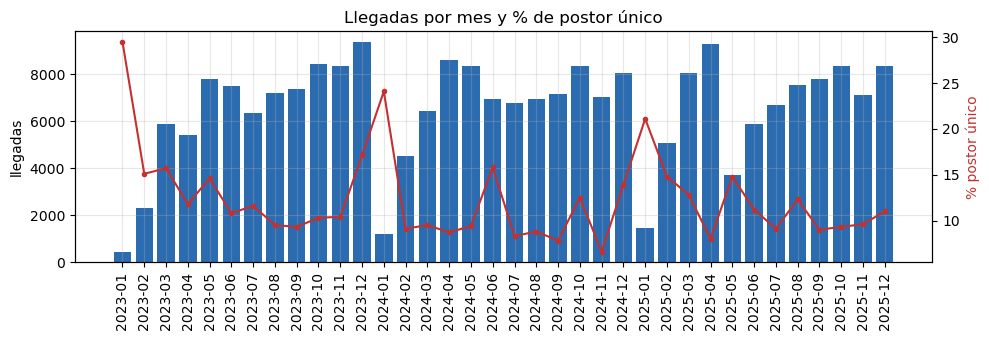

In [7]:
llegadas_mes = (flujo_pd.groupby(["anio", "mes"])
                .agg(llegadas=("bit", "size"), postor_unico=("bit", "sum")).reset_index())
llegadas_mes["pct_postor_unico"] = (100 * llegadas_mes["postor_unico"] / llegadas_mes["llegadas"]).round(1)
print(llegadas_mes["llegadas"].describe()[["mean", "min", "50%", "max"]].round(0).to_string())

etiquetas = llegadas_mes["anio"].astype(str) + "-" + llegadas_mes["mes"].astype(str).str.zfill(2)
fig, ax = plt.subplots(figsize=(10, 3.5))
ax.bar(etiquetas, llegadas_mes["llegadas"], color="#2b6cb0")
ax.set_ylabel("llegadas"); ax.tick_params(axis="x", rotation=90)
ax2 = ax.twinx(); ax2.plot(etiquetas, llegadas_mes["pct_postor_unico"], color="#c53030", marker="o", ms=3)
ax2.set_ylabel("% postor único", color="#c53030"); ax2.grid(False)
plt.title("Llegadas por mes y % de postor único")
mostrar_fig("llegadas_mes")

- 235,954 llegadas en 36 meses: promedio 6,554 y mediana de 7,138 por mes

- Enero es siempre el mes de menor volumen (440, 1,198 y 1,445) y el de mayor % de postor único (29.5%, 24.1% y 21.1%)

- Diciembre combina alto volumen y % alto (17.1% en 2023, 13.9% en 2024), consistente con el cierre del año fiscal

- El volumen no es constante: una ventana de `N` llegadas no es exactamente un mes calendario

### 2. Parámetros

In [8]:
N = int(round(llegadas_mes["llegadas"].mean(), -2)) 

N_SEMANA = int(round(N * 7 / 30, -2))
N_TRIMESTRE = 3 * N
R = 2

print(f"N (ventana principal) = {N:,} llegadas | semana = {N_SEMANA:,} | trimestre = {N_TRIMESTRE:,} | r = {R}")

N (ventana principal) = 6,600 llegadas | semana = 1,500 | trimestre = 19,800 | r = 2


- **Ventana `N`**: Se cuenta sobre los últimos `N` *elementos*; se fija `N` = promedio de llegadas por mes

- **Sensibilidad**: Se prueba también 1 semana y 1 trimestre

- **`r = 2`**: Máximo 2 buckets por tamaño, con error relativo ≤ 50%

### 3. DGIM

- Cada bucket guarda `(timestamp del 1 más reciente, tamaño)`; los tamaños son potencias de 2

- Se descarta el bucket más antiguo cuando su timestamp sale de la ventana

- Estimado = suma de todos los buckets menos la mitad del más antiguo

- `r` generaliza la regla: se fusiona al tener `r+1` buckets del mismo tamaño (`r=2` es el clásico); se usa solo en §5

In [9]:
class DGIM:
    def __init__(self, N, r=2):
        self.N, self.r = N, r
        self.t = 0
        self.buckets = []

    def agregar(self, bit):
        self.t += 1
        if self.buckets and self.buckets[-1][0] <= self.t - self.N:
            self.buckets.pop()
        if bit:
            self.buckets.insert(0, (self.t, 1))
            self.fusionar()

    def fusionar(self):
        b, i, tam = self.buckets, 0, 1
        while True:
            j = i
            while j < len(b) and b[j][1] == tam:
                j += 1
            if j - i <= self.r:
                return
            b[j - 2] = (b[j - 2][0], 2 * tam)
            del b[j - 1]
            i, tam = j - 2, 2 * tam

    def estimar(self):
        if not self.buckets:
            return 0.0
        return sum(s for _, s in self.buckets) - self.buckets[-1][1] / 2

    def bits_por_bucket(self):
        return math.ceil(math.log2(self.N)) + math.ceil(math.log2(math.log2(self.N)))

### 4. Simulación de llegada

- Se consulta a DGIM al cierre de cada día: postores únicos en los últimos `N` procesos

- Conteo exacto: `pref[t] - pref[t-N]`, con `pref` = postores únicos acumulados

In [10]:
dias = flujo_pd.groupby(flujo_pd["fecha"].dt.normalize())["t"].max()
consultas = dias.to_numpy()
pref = np.concatenate([[0], np.cumsum(bits)])

def exacto_ventana(N):
    return pref[consultas] - pref[np.maximum(consultas - N, 0)]

def simular(bits, N, r):
    dgim, est, q, max_buckets = DGIM(N, r), np.empty(len(consultas)), 0, 0
    t0 = time.perf_counter()
    for t, b in enumerate(bits, start=1):
        dgim.agregar(b)
        if len(dgim.buckets) > max_buckets:
            max_buckets = len(dgim.buckets)
        if q < len(consultas) and consultas[q] == t:
            est[q] = dgim.estimar()
            q += 1
    seg = time.perf_counter() - t0
    return est, max_buckets, max_buckets * dgim.bits_por_bucket(), seg

def errores(est, exacto):
    ok = exacto > 0
    return np.abs(est[ok] - exacto[ok]) / exacto[ok]

estimado, max_buckets, bits_dgim, seg_dgim = simular(bits, N, R)
exacto = exacto_ventana(N)

serie = pd.DataFrame({"fecha": dias.index, "t": consultas, "exacto": exacto, "estimado": estimado})
serie["error_rel"] = np.where(serie["exacto"] > 0, (serie["estimado"] - serie["exacto"]).abs() / serie["exacto"], 0.0)
serie["ventana_llena"] = serie["t"] >= N
serie["pct_postor_unico"] = 100 * serie["exacto"] / np.minimum(serie["t"], N)

err = errores(estimado, exacto)
assert err.max() <= 0.5, "DGIM clásico debe respetar la cota de 50%"
print(f"Consultas: {len(serie):,} | error relativo medio {100 * err.mean():.2f}% | p95 {100 * np.percentile(err, 95):.2f}% "
      f"| máx {100 * err.max():.2f}% (cota 50%)")
print(f"Buckets (máx): {max_buckets} -> {bits_dgim} bits | exacto: {N:,} bits | {1e6 * seg_dgim / N_FLUJO:.2f} µs/elemento")

Consultas: 860 | error relativo medio 10.89% | p95 22.23% | máx 34.65% (cota 50%)
Buckets (máx): 19 -> 323 bits | exacto: 6,600 bits | 1.71 µs/elemento


#### a. Evolución en el tiempo

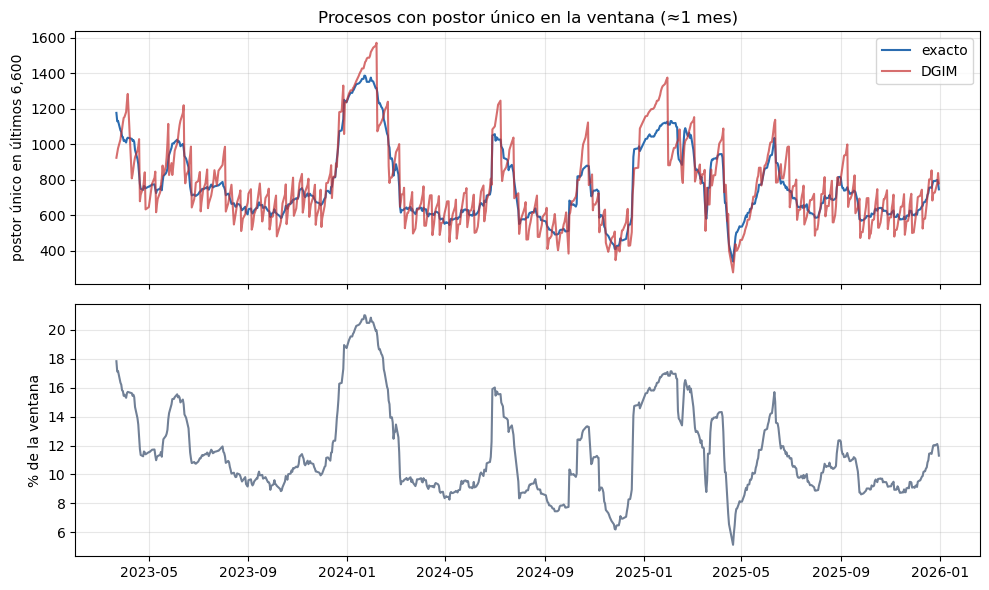

In [11]:
s = serie[serie["ventana_llena"]]
fig, ax = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
ax[0].plot(s["fecha"], s["exacto"], color="#2b6cb0", label="exacto")
ax[0].plot(s["fecha"], s["estimado"], color="#c53030", alpha=.7, label="DGIM")
ax[0].set_ylabel(f"postor único en últimos {N:,}"); ax[0].legend()
ax[0].set_title("Procesos con postor único en la ventana (≈1 mes)")
ax[1].plot(s["fecha"], s["pct_postor_unico"], color="#718096")
ax[1].set_ylabel("% de la ventana")
mostrar_fig("evolucion_ventana")

- La ventana se llena el 2023-03-22; desde ahí, el % de postor único oscila entre 5.1% y 21.0%

- DGIM reproduce la forma de la serie exacta; mismos picos y valles, aunque se desvía en el nivel

- Los picos caen en enero y los valles en abril y noviembre

#### b. Error

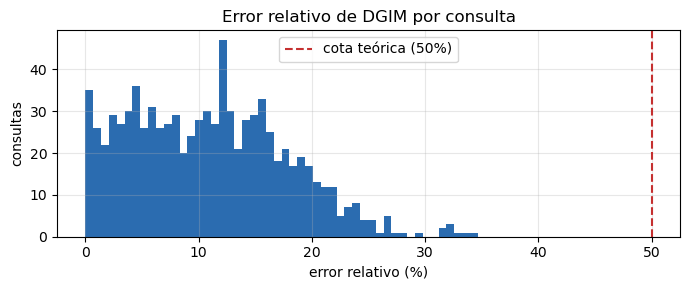

In [12]:
plt.figure(figsize=(7, 3))
plt.hist(100 * err, bins=50, color="#2b6cb0")
plt.axvline(50, color="#c53030", linestyle="--", label="cota teórica (50%)")
plt.xlabel("error relativo (%)"); plt.ylabel("consultas"); plt.legend()
plt.title("Error relativo de DGIM por consulta")
mostrar_fig("error_dgim")

- 860 consultas: error relativo medio 10.9%, p95 22.2% y máximo 34.6%

### 5. Precisión, memoria y tiempo

- Memoria: nº de buckets × (log₂N + log₂log₂N) bits en DGIM; `N` bits de la ventana en exacto

- Varía la ventana (semana / mes / trimestre) y `r` ∈ {2, 3, 5, 10}

- Validación: ventana en `deque` con suma incremental

In [13]:
def tiempo_exacto(bits, N):
    ventana, total = deque(), 0
    t0 = time.perf_counter()
    for b in bits:
        ventana.append(b); total += b
        if len(ventana) > N:
            total -= ventana.popleft()
    return time.perf_counter() - t0

filas = []
for nombre_v, N_ in [("semana", N_SEMANA), ("mes", N), ("trimestre", N_TRIMESTRE)]:
    exacto_ = exacto_ventana(N_)
    seg_ex = tiempo_exacto(bits, N_)
    for r in [2, 3, 5, 10]:
        est_, nb_, bits_, seg_ = simular(bits, N_, r)
        e = errores(est_, exacto_)
        filas.append({"ventana": nombre_v, "N": N_, "r": r, "cota": 1 / (2 * (r - 1)),
                      "error_medio": e.mean(), "error_p95": np.percentile(e, 95), "error_max": e.max(),
                      "buckets_max": nb_, "bits_dgim": bits_, "bits_exacto": N_,
                      "us_por_elemento": 1e6 * seg_ / N_FLUJO, "us_por_elemento_exacto": 1e6 * seg_ex / N_FLUJO})

tradeoff = pd.DataFrame(filas)
tradeoff.round(4)

,ventana,N,r,cota,error_medio,error_p95,error_max,buckets_max,bits_dgim,bits_exacto,us_por_elemento,us_por_elemento_exacto
0,semana,1500,2,0.5000,0.1075,0.2245,0.3333,16,240,1500,1.7266,0.0514
1,semana,1500,3,0.2500,0.0681,0.1457,0.2296,22,330,1500,1.7384,0.0514
2,semana,1500,5,0.1250,0.0409,0.0870,0.1667,33,495,1500,1.7507,0.0514
3,semana,1500,10,0.0556,0.0205,0.0435,0.1667,56,840,1500,1.8903,0.0514
4,mes,6600,2,0.5000,0.1089,0.2223,0.3465,19,323,6600,1.8920,0.0585
5,mes,6600,3,0.2500,0.0692,0.1517,0.2007,27,459,6600,1.7800,0.0585
6,mes,6600,5,0.1250,0.0427,0.0904,0.1667,41,697,6600,1.7719,0.0585
7,mes,6600,10,0.0556,0.0219,0.0448,0.1667,71,1207,6600,1.8857,0.0585
8,trimestre,19800,2,0.5000,0.1148,0.2288,0.3333,21,399,19800,1.6894,0.0565
9,trimestre,19800,3,0.2500,0.0690,0.1380,0.2000,30,570,19800,1.7459,0.0565


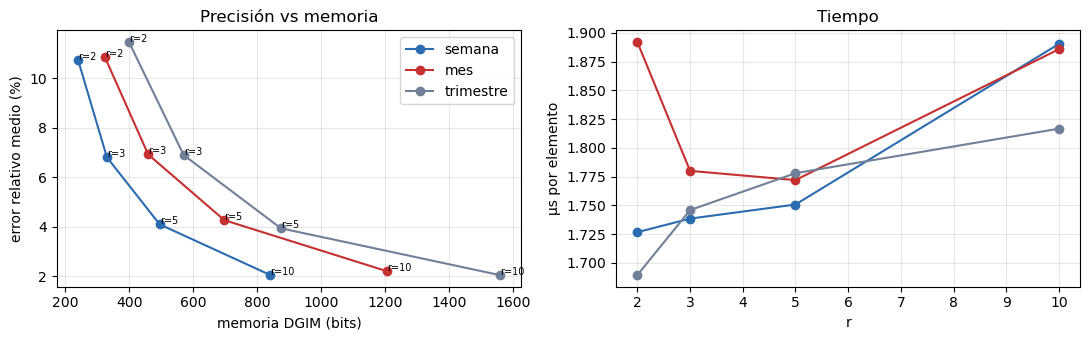

In [14]:
fig, ax = plt.subplots(1, 2, figsize=(11, 3.5))
for (nombre_v, g), color in zip(tradeoff.groupby("ventana", sort=False), ["#2b6cb0", "#c53030", "#718096"]):
    ax[0].plot(g["bits_dgim"], 100 * g["error_medio"], marker="o", color=color, label=nombre_v)
    for _, f in g.iterrows():
        ax[0].annotate(f"r={f['r']}", (f["bits_dgim"], 100 * f["error_medio"]), fontsize=7)
    ax[1].plot(g["r"], g["us_por_elemento"], marker="o", color=color, label=nombre_v)
ax[0].set_xlabel("memoria DGIM (bits)"); ax[0].set_ylabel("error relativo medio (%)"); ax[0].legend()
ax[0].set_title("Precisión vs memoria")
ax[1].set_xlabel("r"); ax[1].set_ylabel("µs por elemento"); ax[1].set_title("Tiempo")
mostrar_fig("tradeoff_dgim")

- Subir `r` baja el error; con N=6,600, de 10.9% (r=2) a 6.9% (r=3), 4.3% (r=5) y 2.2% (r=10)

- La memoria crece con `r`: 323 → 459 → 697 → 1,207 bits; siempre es menor que con el conteo exacto

- La memoria crece como log² N: el ahorro sube dada una ventana mas angosta 

- Semana 240 bits vs 1,500 bits (ahorro 6x) y Trimestre 399 bits vs 19,800 bits (ahorro 50x)

- El error medio casi no depende de `N`

- Tiempo: 0.32 → 0.40 µs por elemento; el exacto con `deque` tarda ~0.08 µs 

### 6. Diferentes ventanas

- Se repite la simulación (r=2) con ventanas de 1 semana, 1 mes y 1 trimestre

- Se mide cómo varia el hallazgo: nivel de postor único, picos y alertas

- Alerta: día en que la ventana supera `15%` de postor único

In [15]:
UMBRAL_ALERTA = 15

filas, series_v = [], []
for nombre_v, N_ in [("semana", N_SEMANA), ("mes", N), ("trimestre", N_TRIMESTRE)]:
    est_, *_ = simular(bits, N_, R)
    lleno = consultas >= N_
    fechas = dias.index[lleno]
    pct_ex = 100 * exacto_ventana(N_)[lleno] / N_
    pct_est = 100 * est_[lleno] / N_
    alerta_ex, alerta_est = pct_ex > UMBRAL_ALERTA, pct_est > UMBRAL_ALERTA
    series_v.append(pd.DataFrame({"ventana": nombre_v, "N": N_, "fecha": fechas, "pct_exacto": pct_ex, "pct_dgim": pct_est}))
    filas.append({"ventana": nombre_v, "N": N_,
                  "pct_medio": pct_ex.mean(), "pct_desv": pct_ex.std(), "pct_min": pct_ex.min(), "pct_max": pct_ex.max(),
                  "fecha_max_exacto": fechas[pct_ex.argmax()], "fecha_max_dgim": fechas[pct_est.argmax()],
                  "dias_alerta_exacto": int(alerta_ex.sum()), "dias_alerta_dgim": int(alerta_est.sum()),
                  "alertas_acertadas": int((alerta_ex & alerta_est).sum())})

variacion = pd.DataFrame(filas)
serie_ventanas = pd.concat(series_v, ignore_index=True)
variacion.round(2)

,ventana,N,pct_medio,pct_desv,pct_min,pct_max,fecha_max_exacto,fecha_max_dgim,dias_alerta_exacto,dias_alerta_dgim,alertas_acertadas
0,semana,1500,11.58,4.80,1.93,30.60,2024-07-01,2025-03-24,145,143,117
1,mes,6600,11.50,3.13,5.14,21.02,2024-01-22,2024-02-06,129,136,108
2,trimestre,19800,11.10,1.56,8.26,14.87,2025-03-26,2024-02-20,0,39,0


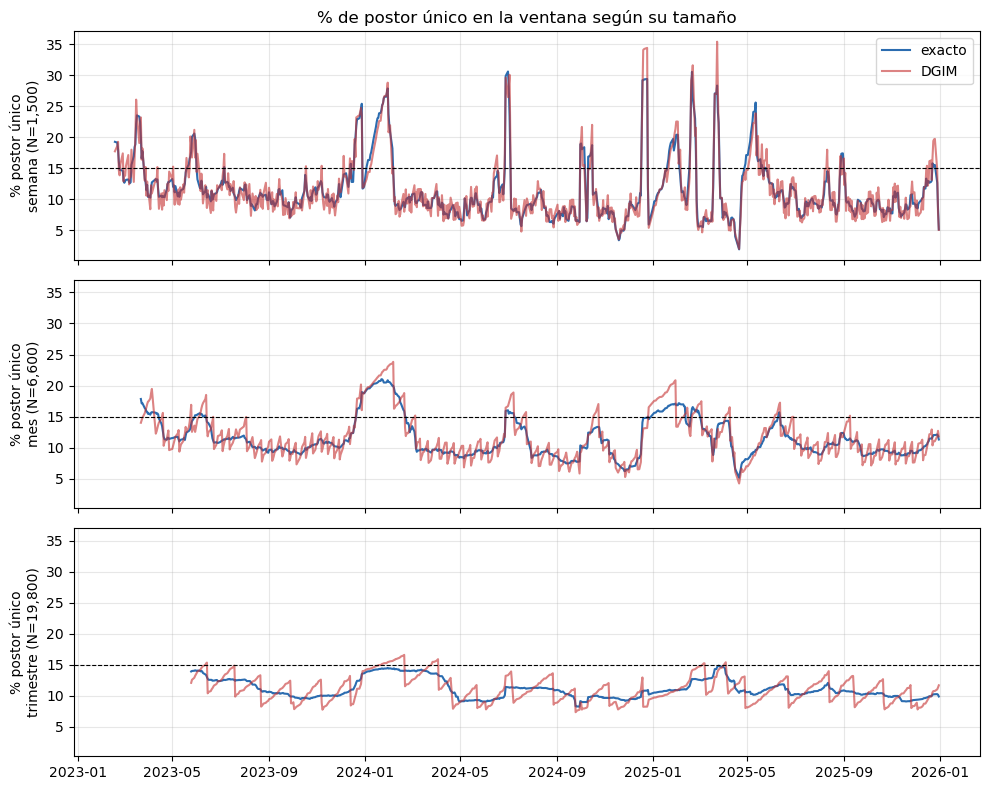

In [16]:
fig, ax = plt.subplots(3, 1, figsize=(10, 8), sharex=True, sharey=True)
for a_, (nombre_v, g) in zip(ax, serie_ventanas.groupby("ventana", sort=False)):
    a_.plot(g["fecha"], g["pct_exacto"], color="#2b6cb0", label="exacto")
    a_.plot(g["fecha"], g["pct_dgim"], color="#c53030", alpha=.6, label="DGIM")
    a_.axhline(UMBRAL_ALERTA, color="black", linewidth=.8, linestyle="--")
    a_.set_ylabel(f"% postor único\n{nombre_v} (N={g['N'].iloc[0]:,})")
ax[0].legend(); ax[0].set_title("% de postor único en la ventana según su tamaño")
mostrar_fig("variacion_ventana")

- Promedio casi no cambia (11.6%, 11.5% y 11.1%). La desviación baja de 4.8 (semana) a 3.1 (mes) y 1.6 (trimestre)

- El pico depende de la ventana: semana → 30.6% el 2024-07-01; mes → 21.0% el 2024-01-22; trimestre → 14.9% el 2025-03-26

- Alertas: 145 días con ventana semanal, 129 con mensual y 0 con trimestral

### 7. Escritura de resultados

- El flujo ordenado se escribe en `temp/a_dgim/flujo`

- Tablas en `temp/a_dgim/tablas/` y `temp/a_dgim/web/`

In [17]:
flujo.write.mode("overwrite").parquet(str(out_dir / "flujo"))

principal = tradeoff[(tradeoff["ventana"] == "mes") & (tradeoff["r"] == R)].iloc[0]
resumen = pd.DataFrame([{
    "estructura": "DGIM", "tarea": "postor único en ventana", "parametros": f"N={N}, r={R}",
    "metrica_error": "error relativo medio", "error": float(err.mean()),
    "memoria_bytes": bits_dgim / 8, "memoria_exacta_bytes": N / 8,
    "us_por_elemento": float(principal["us_por_elemento"]), "us_por_elemento_exacto": float(principal["us_por_elemento_exacto"])}])

tablas = {"llegadas_mes": llegadas_mes, "serie": serie, "tradeoff": tradeoff,
          "variacion": variacion, "serie_ventanas": serie_ventanas, "resumen": resumen}
escritos = {nombre: guardar_tabla(df, nombre) for nombre, df in tablas.items()}
print(f"Escrito en temp/a_dgim/: flujo, {', '.join(escritos)}")

Escrito en temp/a_dgim/: flujo, llegadas_mes, serie, tradeoff, variacion, serie_ventanas, resumen


#### a. Verificación

In [18]:
chk_flujo = spark.read.parquet(str(out_dir / "flujo")).count()
assert chk_flujo == N_FLUJO, f"flujo: esperaba {N_FLUJO}, leí {chk_flujo}"

for nombre, n in escritos.items():
    leido = spark.read.parquet(str(tab_dir / nombre)).count()
    assert leido == n, f"{nombre}: esperaba {n}, leí {leido}"
    assert (web_dir / f"{nombre}.json").exists(), f"falta web/{nombre}.json"

figs = sorted(p.stem for p in fig_dir.glob("*.png"))
print(f"OK: {len(escritos)} tablas (parquet + json) | {len(figs)} figuras: {', '.join(figs)}")

OK: 6 tablas (parquet + json) | 5 figuras: error_dgim, evolucion_ventana, llegadas_mes, tradeoff_dgim, variacion_ventana


---
### 8. Cerrar sesión

In [19]:
spark.stop()